In [17]:
# check if the data folder exists, if not create it
import os
import urllib.request
import zipfile
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [18]:
if not os.path.exists("../data"):
    os.makedirs("../data")

# check if the dataset.zip is existed, if not, download the data
if not os.path.exists("../data/bank+marketing.zip"):
    print("Downloading dataset...")
    url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    urllib.request.urlretrieve(url, "../data/bank+marketing.zip")

# Only unzip bank-additional.zip from the container zip
if not os.path.exists("../data/raw/bank-additional"):
    # Extract only bank-additional.zip from the main zip file
    with zipfile.ZipFile("../data/bank+marketing.zip", "r") as zip_ref:
        zip_ref.extract("bank-additional.zip", "../data")

    # Then extract the contents of bank-additional.zip
    with zipfile.ZipFile("../data/bank-additional.zip", "r") as zip_ref:
        zip_ref.extractall("../data/raw")

In [19]:
# load the dataset into a pandas dataframe
data = pd.read_csv("../data/raw/bank-additional/bank-additional-full.csv", sep=";")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

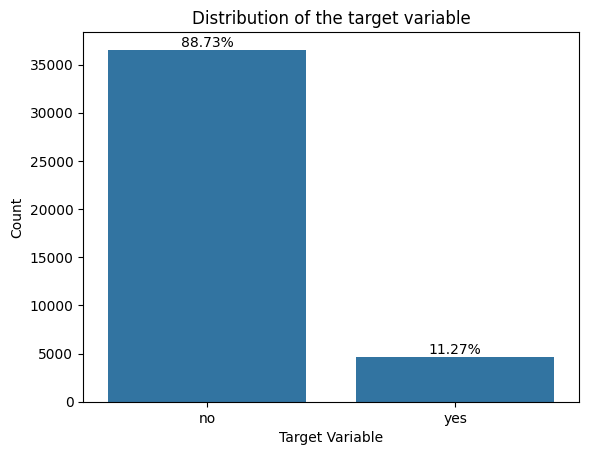

In [14]:
# plot the distribution of the target variable and include the percentage of each class
sns.countplot(x="y", data=data)
plt.title("Distribution of the target variable")
plt.xlabel("Target Variable")
plt.ylabel("Count")

# Calculate the percentage of each class
class_counts = data["y"].value_counts()
class_percentages = (class_counts / class_counts.sum() * 100).round(2)

# Add percentage labels on top of each bar
ax = plt.gca()
for i, (class_label, count) in enumerate(class_counts.items()):
    percentage = class_percentages[class_label]
    ax.text(i, count + 10, f'{percentage}%', ha='center', va='bottom')

plt.show()

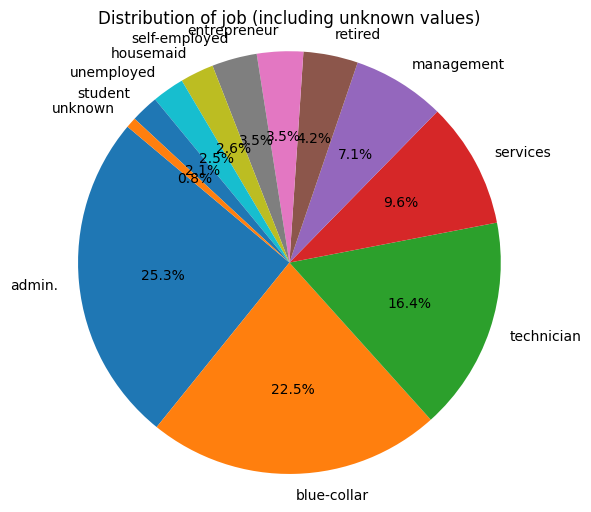

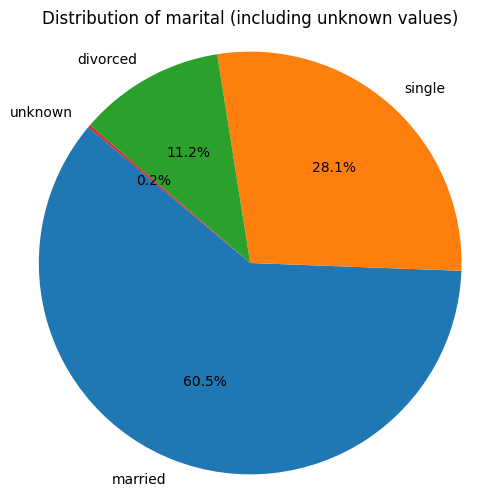

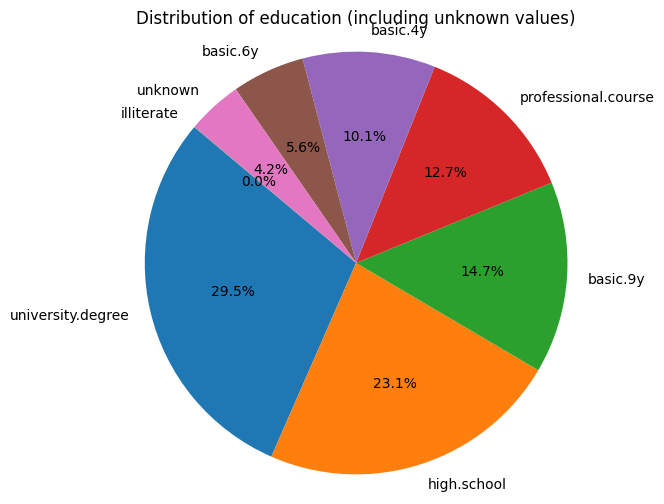

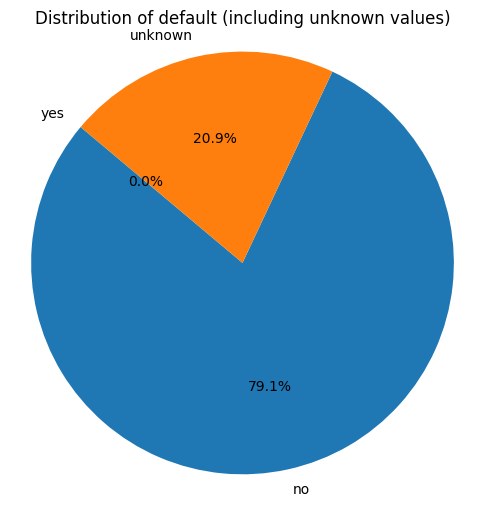

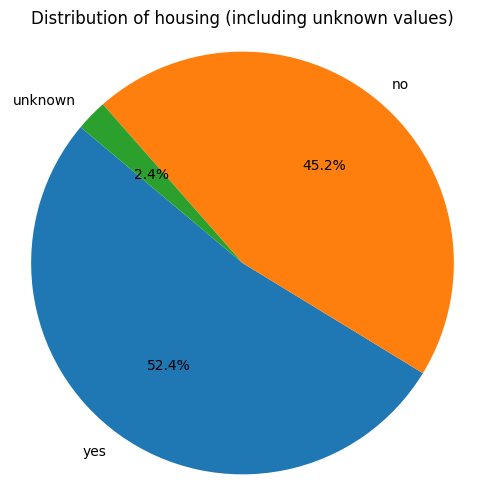

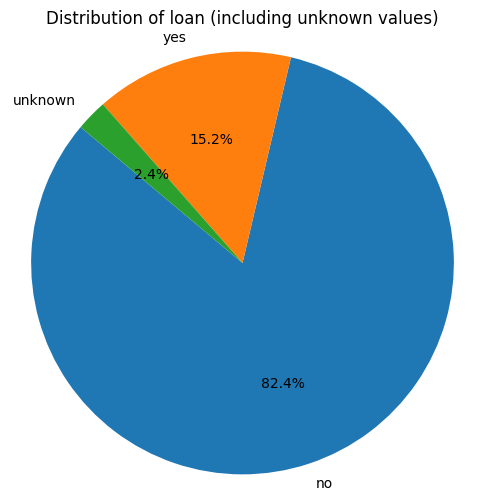

In [15]:
# plot pie chart for the features that contain unknown values and include the percentage of each class
features_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for feature in features_with_unknown:
    plt.figure(figsize=(6, 6))
    feature_counts = data[feature].value_counts()
    feature_percentages = (feature_counts / feature_counts.sum() * 100).round(2)
    plt.pie(feature_counts, labels=feature_counts.index, autopct='%1.1f%%', startangle=140)
    plt.title(f"Distribution of {feature} (including unknown values)")
    plt.axis('equal')
    plt.show()

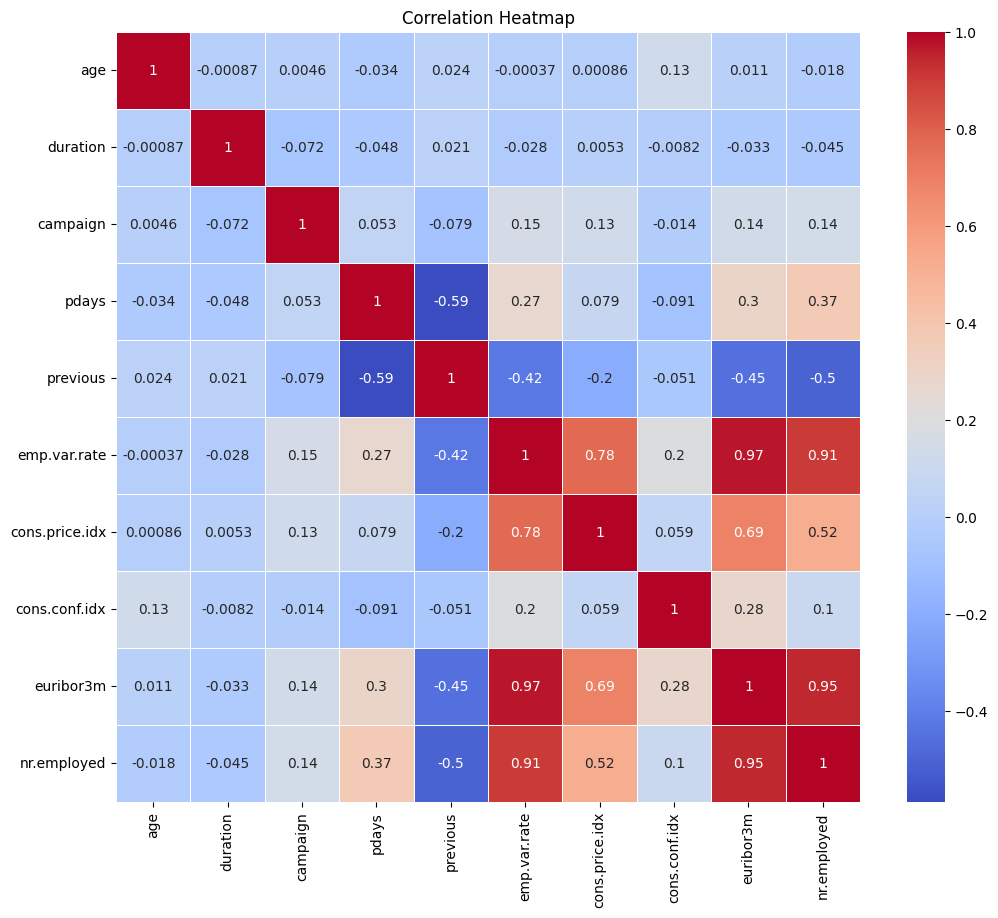

In [16]:
# plot the heatmap of the correlations between the features and the target variable
plt.figure(figsize=(12, 10))
# make a numeric copy: map target `y` to binary and select numeric cols only
data_numeric = data.copy()
if data_numeric['y'].dtype == object:
    data_numeric['y'] = data_numeric['y'].map({'yes': 1, 'no': 0})
correlation_matrix = data_numeric.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()